In [2]:
import kagglehub
path = kagglehub.dataset_download("ashishjangra27/face-mask-12k-images-dataset")
print(path)

100%|██████████| 330M/330M [00:08<00:00, 39.6MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/ashishjangra27/face-mask-12k-images-dataset/versions/1


In [3]:
dataset_path = path

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os

In [5]:
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
print(os.listdir(path))

['Face Mask Dataset']


In [7]:
dataset_path = os.path.join(path, "Face Mask Dataset")
print(os.listdir(dataset_path))

['Validation', 'Test', 'Train']


In [8]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, "Train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, "Validation"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, "Test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 10000 files belonging to 2 classes.
Found 800 files belonging to 2 classes.
Found 992 files belonging to 2 classes.


In [9]:
class_names = train_ds.class_names

print(class_names)

['WithMask', 'WithoutMask']


In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

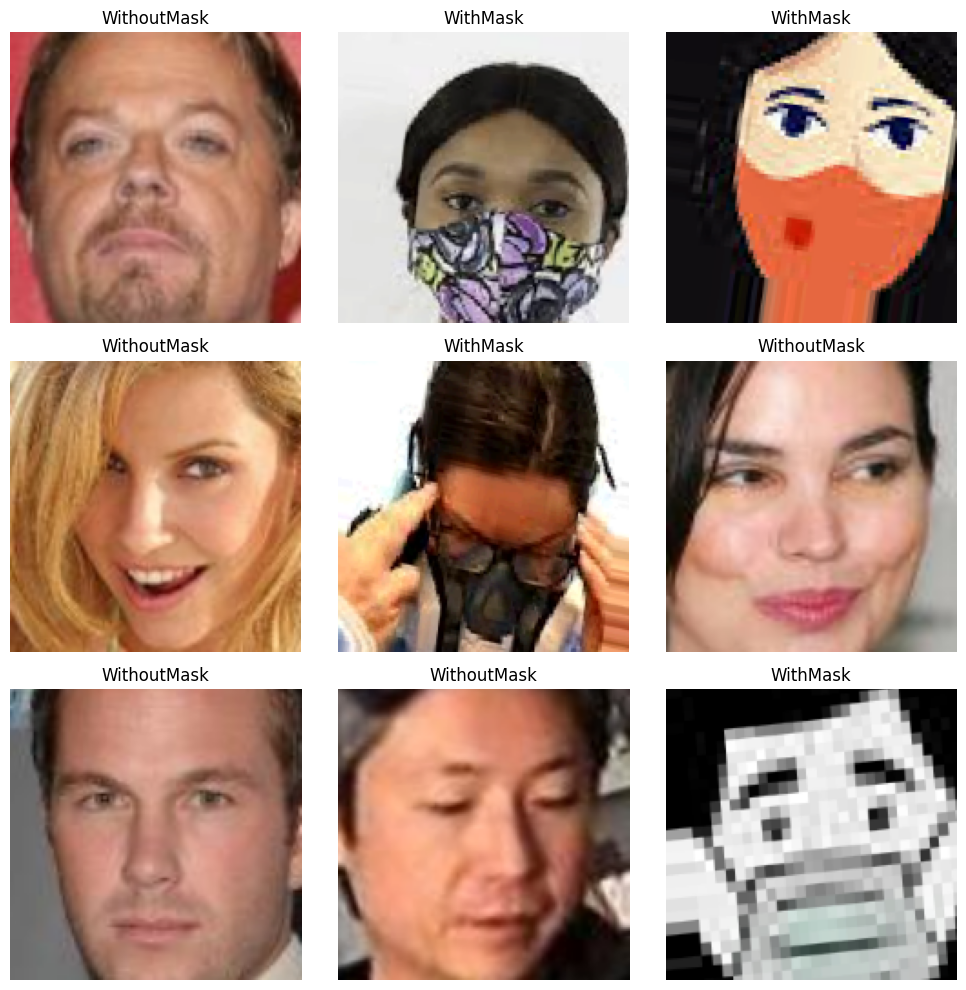

In [11]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

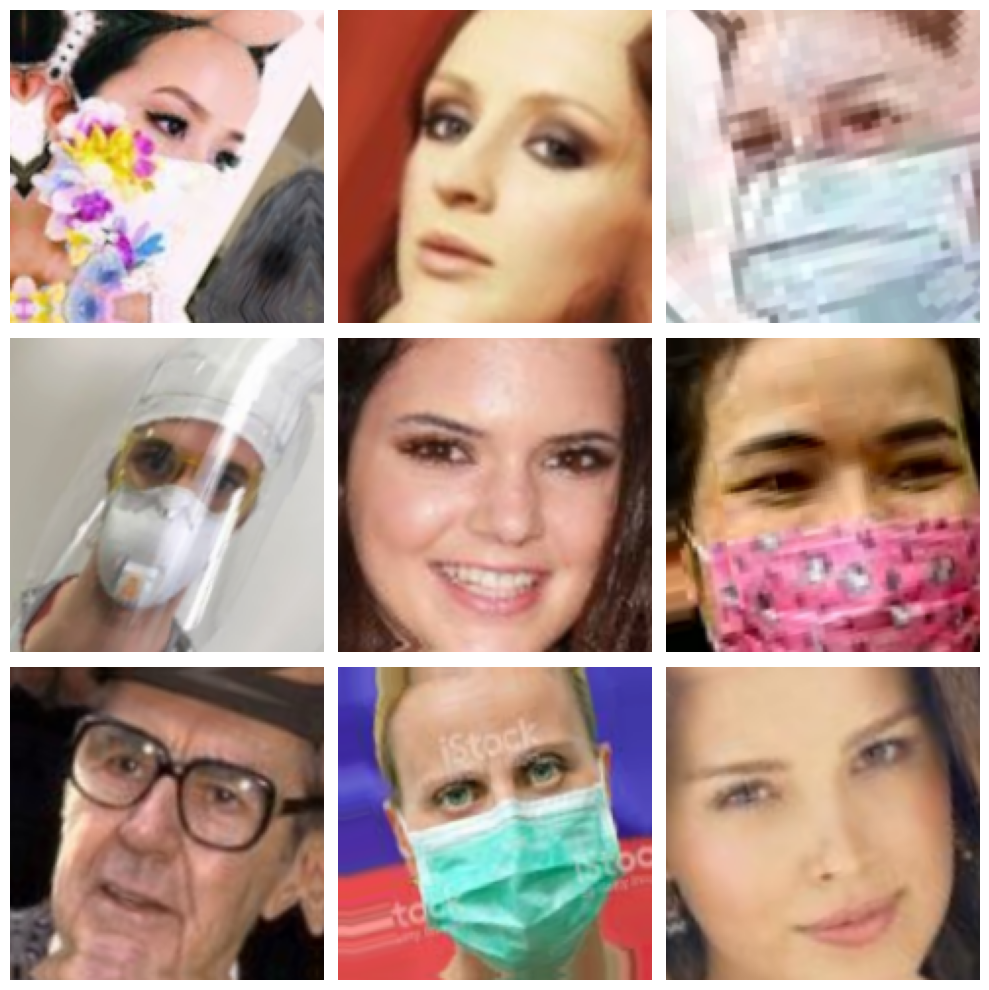

In [13]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    augmented_images = data_augmentation(images)

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(augmented_images[i].numpy().astype("uint8"))

        plt.axis("off")

plt.tight_layout()

plt.show()

In [14]:
from tensorflow.keras.applications import MobileNetV2

In [15]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(160, 160, 3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [16]:
base_model.trainable = False

In [17]:
model = keras.Sequential([
    data_augmentation,

    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

In [18]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (16, 160, 160, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (16, 160, 160, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (16, 5, 5, 1280)       │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (16, 1280)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (16, 1280)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (16, 1)                │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [19]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [20]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [21]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [22]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/5
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9218 - loss: 0.1886
Epoch 1: val_accuracy improved from None to 0.98750, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 31ms/step - accuracy: 0.9668 - loss: 0.0952 - val_accuracy: 0.9875 - val_loss: 0.0278
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9819 - loss: 0.0536
Epoch 2: val_accuracy improved from 0.98750 to 0.99250, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.9841 - loss: 0.0466 - val_accuracy: 0.9925 - val_loss: 0.0161
Epoch 3/5
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9873 - loss: 0.0384
Epoch 3: val_accuracy improved from 0.99250 to 0.99875, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.9878 - loss: 0.0359 - val_a

In [23]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9889 - loss: 0.0213
Test Loss: 0.021292444318532944
Test Accuracy: 0.9889112710952759


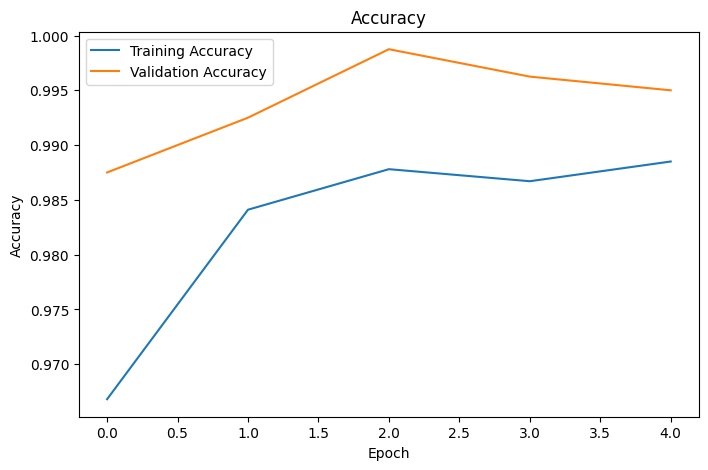

In [24]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

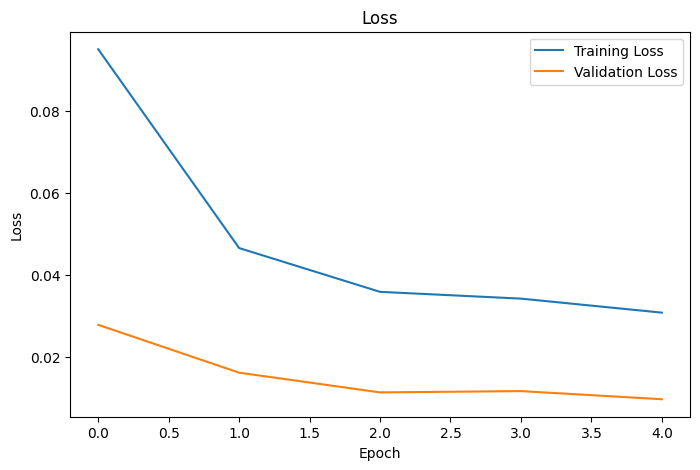

In [25]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [26]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predictions = (predictions > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(predictions.flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

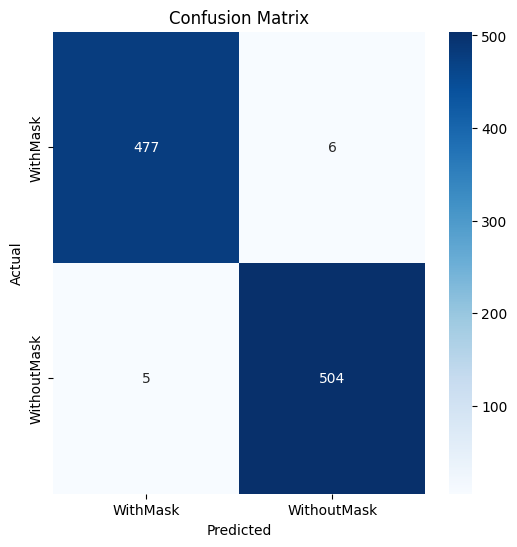

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [28]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

    WithMask       0.99      0.99      0.99       483
 WithoutMask       0.99      0.99      0.99       509

    accuracy                           0.99       992
   macro avg       0.99      0.99      0.99       992
weighted avg       0.99      0.99      0.99       992



/tmp/ipykernel_3944/2457478191.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predicted = class_names[int(prediction > 0.5)]


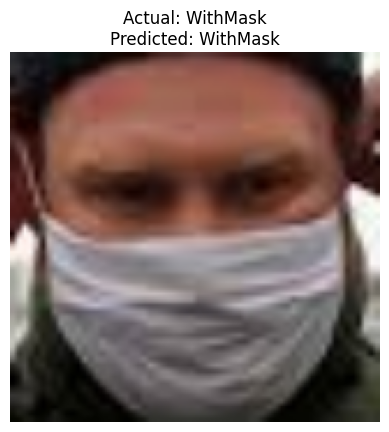

In [29]:
import random

for images, labels in test_ds.take(1):

    index = random.randint(0, len(images)-1)

    plt.imshow(images[index].numpy().astype("uint8"))
    plt.axis("off")

    prediction = model.predict(images[index][None, ...], verbose=0)

    predicted = class_names[int(prediction > 0.5)]

    actual = class_names[labels[index]]

    plt.title(f"Actual: {actual}\nPredicted: {predicted}")

plt.show()

In [30]:
plt.savefig("accuracy_plot.png")
plt.savefig("loss_plot.png")
plt.savefig("confusion_matrix.png")

<Figure size 640x480 with 0 Axes>

In [31]:
base_model.trainable = True

In [32]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [33]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [34]:
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/5
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8423 - loss: 0.5797
Epoch 1: val_accuracy did not improve from 0.99875
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - accuracy: 0.9235 - loss: 0.2557 - val_accuracy: 0.9937 - val_loss: 0.0185
Epoch 2/5
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9756 - loss: 0.0635
Epoch 2: val_accuracy improved from 0.99875 to 1.00000, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.9756 - loss: 0.0654 - val_accuracy: 1.0000 - val_loss: 0.0048
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9853 - loss: 0.0457
Epoch 3: val_accuracy did not improve from 1.00000
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 40ms/step - accuracy: 0.9848 - loss: 0.0434 - val_accuracy: 1.0000 - val_loss: 0.0030
Epoch 4/5
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9818 - loss: 0.0501
Epoch 4: val_accuracy did not improve from 1.00000
625/6

In [35]:
model.save("face_mask_detector.keras")

In [36]:
%%writefile app.py

Writing app.py


In [37]:
%%writefile app.py

import streamlit as st

st.title("Face Mask Detection")

Overwriting app.py


In [38]:
%%writefile requirements.txt
streamlit
tensorflow
numpy
pillow

Writing requirements.txt


In [39]:
%%writefile README.md
# Face Mask Detection

Writing README.md
